# Visual Product Search Engine

## Objective

The goal of this project is to build an image similarity search engine capable of retrieving visually similar products using deep learning embeddings and FAISS.

This notebook focuses on understanding the Stanford Online Products dataset before building the retrieval pipeline.


In [1]:
import random 
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
%matplotlib inline

In [3]:
Dataset_path=Path(r"C:\Users\goura\OneDrive\Desktop\image_Similarity\visual-product-search\data\raw\Stanford_Online_Products")

In [4]:
train_df=pd.read_csv(Dataset_path/"Ebay_train.txt",sep=" ")
test_df=pd.read_csv(Dataset_path /"Ebay_test.txt",sep=" ")


In [5]:
train_df.head()

,image_id,class_id,super_class_id,path
0,1,1,1,bicycle_final/111085122871_0.JPG
1,2,1,1,bicycle_final/111085122871_1.JPG
2,3,1,1,bicycle_final/111085122871_2.JPG
3,4,1,1,bicycle_final/111085122871_3.JPG
4,5,1,1,bicycle_final/111085122871_4.JPG


In [6]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59551 entries, 0 to 59550
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   image_id        59551 non-null  int64
 1   class_id        59551 non-null  int64
 2   super_class_id  59551 non-null  int64
 3   path            59551 non-null  str  
dtypes: int64(3), str(1)
memory usage: 3.6 MB


In [7]:
train_df.isnull().sum()

image_id          0
class_id          0
super_class_id    0
path              0
dtype: int64

In [8]:
print("="*50)
print(f"training Images :{len(train_df):,}")
print(f"test Images:{len(test_df):,}")
print("=" * 50)

training Images :59,551
test Images:60,502


In [10]:
print("Training Products : ",train_df["class_id"].nunique())
print("Testing Products:",test_df["class_id"].nunique())


Training Products :  11318
Testing Products: 11316


In [9]:
super_classes = train_df["super_class_id"].value_counts().sort_index()

super_classes

super_class_id
1     4168
2     5848
3     5845
4     4985
5     2993
6     5013
7     6304
8     6731
9     3472
10    4367
11    5470
12    4355
Name: count, dtype: int64

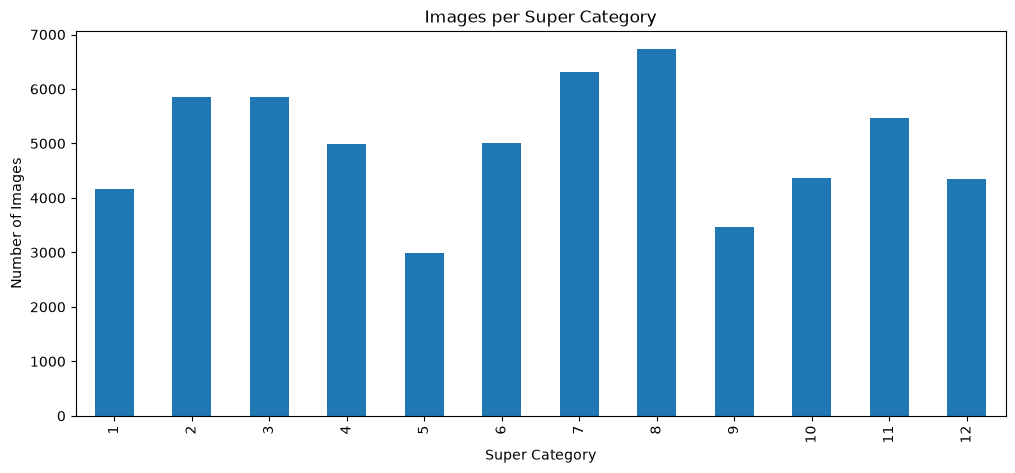

In [10]:
plt.figure(figsize=(12,5))

super_classes.plot(kind="bar")

plt.title("Images per Super Category")

plt.xlabel("Super Category")

plt.ylabel("Number of Images")

plt.show()

In [11]:
img_p=train_df.groupby("class_id").size()

In [12]:
img_p.describe()

count    11318.000000
mean         5.261619
std          2.978530
min          2.000000
25%          3.000000
50%          4.000000
75%          7.000000
max         12.000000
dtype: float64

In [13]:
product_id = random.choice(train_df["class_id"].unique())
same_product = train_df[ train_df["class_id"] == product_id]

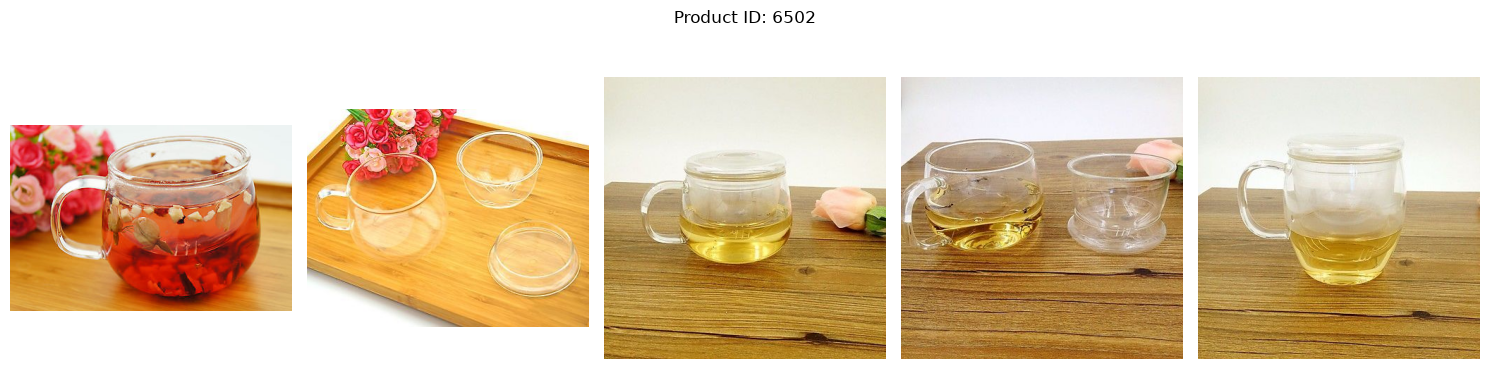

In [30]:
fig, axes = plt.subplots( 1, min(5, len(same_product)), figsize=(15,4))
for ax, (_, row) in zip(np.atleast_1d(axes), same_product.head(5).iterrows()):
    img = Image.open(Dataset_path / row["path"])
    ax.imshow(img)
    ax.axis("off")
plt.suptitle(f"Product ID: {product_id}")
plt.tight_layout()
plt.show()

In [31]:
img_r=train_df["path"].sample(200,random_state=42)
widths=[]
heights=[]
for path in img_r:
    img=Image.open(Dataset_path / path)
    widths.append(img.width)
    heights.append(img.height)

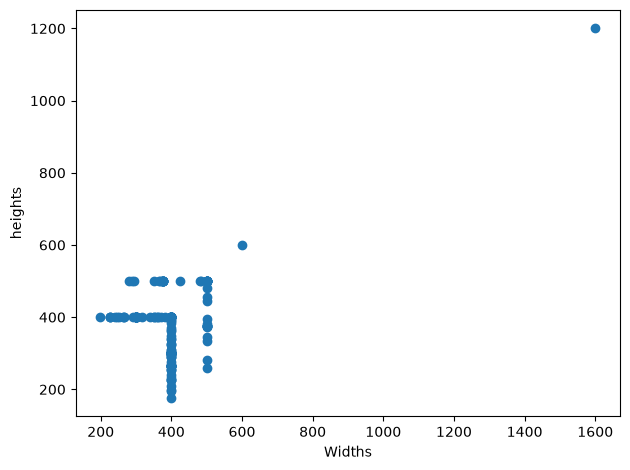

In [32]:
plt.scatter(widths,heights)
plt.xlabel("Widths")
plt.ylabel("heights")
plt.tight_layout()
plt.show()

## Key Findings

- The dataset contains thousands of product images divided into training and testing sets.
- Each product is represented by multiple images captured from different viewpoints.
- Images vary in size and aspect ratio, indicating that resizing will be necessary.
- No major issues with metadata or corrupted images were observed (assuming the check passes).

## Why This Matters

These observations guide the design of the preprocessing pipeline and the choice of feature extraction model. Since retrieval depends on visual similarity rather than classification, preserving discriminative visual features during preprocessing is critical.
